# **업무 이메일 자동화 AI 파이프라인**
---

## Ⅰ. 환경 설정 및 데이터 로드

1. 패키지 설치 + Drive Mount

In [1]:
!pip install sentence-transformers scikit-learn pandas numpy seaborn matplotlib

# 한글 폰트 설치 (Colab 세션 시작마다 실행 필요)
!apt-get update -qq
!apt-get install -y fonts-nanum -qq
!fc-cache -fv

from google.colab import drive
drive.mount('/content/drive')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

2.  sys.path 등록 + 폴더 구조 확인

In [2]:
import os, sys

SRC_DIR = "/content/drive/MyDrive/Capstone_AI2/src"

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from config import (
    BASE_DIR, DATA_DIR, MODEL_DIR, SRC_DIR,
    OUTPUT_DIR, FIGURES_DIR, REPORTS_DIR, LOG_DIR,
    DATASET_PATH, PAIRS_CSV_PATH,
    EMBEDDINGS_BASELINE_PATH, EMBEDDINGS_FINETUNED_PATH,
    SBERT_MODEL_PATH,
    DOMAIN_CLF_PATH, DOMAIN_LE_PATH,
    INTENT_CLF_PATH, INTENT_LE_PATH,
)

print("=" * 55)
print("폴더 구조 확인")
print("=" * 55)
folders = {
    "data/"           : DATA_DIR,
    "models/"         : MODEL_DIR,
    "src/"            : SRC_DIR,
    "outputs/figures/": FIGURES_DIR,
    "outputs/reports/": REPORTS_DIR,
    "outputs/logs/"   : LOG_DIR,
}
for name, path in folders.items():
    status = "✔" if os.path.exists(path) else "❌"
    print(f"  {status}  {name:<22} {path}")

print("\n" + "=" * 55)
print("src 파일 확인")
print("=" * 55)
for fname in ["config.py", "data_utils.py", "train_sbert.py",
              "train_domain.py", "train_intent.py",
              "evaluation.py", "inference.py"]:
    path   = os.path.join(SRC_DIR, fname)
    status = "✔" if os.path.exists(path) else "❌ 없음"
    print(f"  {status}  {fname}")

폴더 구조 확인
  ✔  data/                  /content/drive/MyDrive/Capstone_AI2/data
  ✔  models/                /content/drive/MyDrive/Capstone_AI2/models
  ✔  src/                   /content/drive/MyDrive/Capstone_AI2/src
  ✔  outputs/figures/       /content/drive/MyDrive/Capstone_AI2/outputs/figures
  ✔  outputs/reports/       /content/drive/MyDrive/Capstone_AI2/outputs/reports
  ✔  outputs/logs/          /content/drive/MyDrive/Capstone_AI2/outputs/logs

src 파일 확인
  ✔  config.py
  ✔  data_utils.py
  ✔  train_sbert.py
  ✔  train_domain.py
  ✔  train_intent.py
  ✔  evaluation.py
  ✔  inference.py


3. 데이터 로드 및 검증

In [3]:
from data_utils import load_dataset

df = load_dataset()

print(f"\n[도메인별 샘플 수]")
print(df.groupby("domain")["intent"].count().to_string())
print(f"\n[도메인 × 인텐트 분포]")
print(df.groupby(["domain", "intent"]).size().reset_index(name="count").to_string(index=False))

[load_dataset] 총 샘플: 1500 | 도메인: 7 | 인텐트: 30

[도메인별 샘플 수]
domain
Admin               200
Customer Support    200
Finance             200
HR                  200
IT/Ops              150
Marketing & PR      300
Sales               250

[도메인 × 인텐트 분포]
          domain    intent  count
           Admin        공지     50
           Admin     내부 보고     50
           Admin     자료 요청     50
           Admin     협조 요청     50
Customer Support  기술 지원 요청     50
Customer Support     불만 접수     50
Customer Support    사용법 문의     50
Customer Support     환불 요청     50
         Finance  비용 처리 문의     50
         Finance  세금계산서 요청     50
         Finance  입금 확인 요청     50
         Finance     정산 문의     50
              HR     면접 조율     50
              HR 증명서 발급 요청     50
              HR     채용 문의     50
              HR     휴가 신청     50
          IT/Ops  계정 생성 요청     50
          IT/Ops  권한 변경 요청     50
          IT/Ops 시스템 오류 보고     50
  Marketing & PR     광고 문의     50
  Marketing & PR   보도자료 요청     50
  M

**4. Pair 생성 + CSV 저장**



In [4]:
from data_utils import load_dataset, generate_contrastive_pairs, save_pairs_csv

df          = load_dataset()
train_pairs = generate_contrastive_pairs(df)
save_pairs_csv(train_pairs)

pos = sum(1 for p in train_pairs if p.label == 1.0)
neg = len(train_pairs) - pos
print(f"총 페어    : {len(train_pairs)}")
print(f"Positive  : {pos}")
print(f"Negative  : {neg}")
print(f"Pos:Neg   = 1 : {neg/pos:.1f}")

[load_dataset] 총 샘플: 1500 | 도메인: 7 | 인텐트: 30
[generate_pairs] 총: 5400 | Positive: 900 | Negative: 4500
[save_pairs_csv] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/data/contrastive_pairs.csv
총 페어    : 5400
Positive  : 900
Negative  : 4500
Pos:Neg   = 1 : 5.0


## Ⅱ. SBERT 파인튜닝 및 임베딩 생성

**1. SBERT Fine-tuning**

In [5]:
from train_sbert import run_sbert_finetuning

model = run_sbert_finetuning()

[load_pairs_csv] 복원 완료: 5400개
[split_pairs] Train: 4860 | Val: 540


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[run_sbert_finetuning] 배치: 304 | warmup: 152
저장 경로: /content/drive/MyDrive/Capstone_AI2/models/sbert_business_email



...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[run_sbert_finetuning] 완료 → /content/drive/MyDrive/Capstone_AI2/models/sbert_business_email


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

**2. 임베딩 생성 + data/ 저장**

In [6]:
from train_sbert import generate_embeddings
from config import EMBEDDINGS_FINETUNED_PATH

X = generate_embeddings(
    texts    =df["email_text"].tolist(),
    save_path=EMBEDDINGS_FINETUNED_PATH,
)

print(f"\n임베딩 저장 경로 : {EMBEDDINGS_FINETUNED_PATH}")
print(f"임베딩 shape     : {X.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

[generate_embeddings] shape: (1500, 384)
[save_embeddings] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/data/embeddings_finetuned.npy

임베딩 저장 경로 : /content/drive/MyDrive/Capstone_AI2/data/embeddings_finetuned.npy
임베딩 shape     : (1500, 384)


**3.  임베딩 품질 검증**

In [7]:
from evaluation import validate_embeddings

validate_embeddings(X, df)

SBERT 임베딩 품질 검증
  Shape : (1500, 384) | Mean: 0.0000 | Std: 0.0510

[Cosine Similarity 샘플 검증]
  같은 Intent : 0.8227  ← 높을수록 좋음
  다른 Intent : 0.2405  ← 낮을수록 좋음
  랜덤 (0,100): 0.1542

[도메인별 Intra-class 평균 Cosine Similarity]
  Admin                    : 0.7893
  Customer Support         : 0.8115
  Finance                  : 0.7864
  HR                       : 0.9522
  IT/Ops                   : 0.9831
  Marketing & PR           : 0.8891
  Sales                    : 0.8497


## Ⅲ. 분류기 학습 및 평가

**1. Domain Classifier 학습 + 평가**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Domain Classifier] K-Fold 결과
  Weighted F1 : 0.9038 ± 0.0114
  Macro F1    : 0.8995 ± 0.0126


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Domain Classifier] Classification Report
                  precision    recall  f1-score   support

           Admin       0.87      0.85      0.86       200
Customer Support       0.81      0.90      0.86       200
         Finance       0.97      0.92      0.94       200
              HR       0.92      0.90      0.91       200
          IT/Ops       0.94      0.81      0.87       150
  Marketing & PR       0.92      0.95      0.93       300
           Sales       0.92      0.95      0.93       250

        accuracy                           0.90      1500
       macro avg       0.91      0.90      0.90      1500
    weighted avg       0.91      0.90      0.90      1500



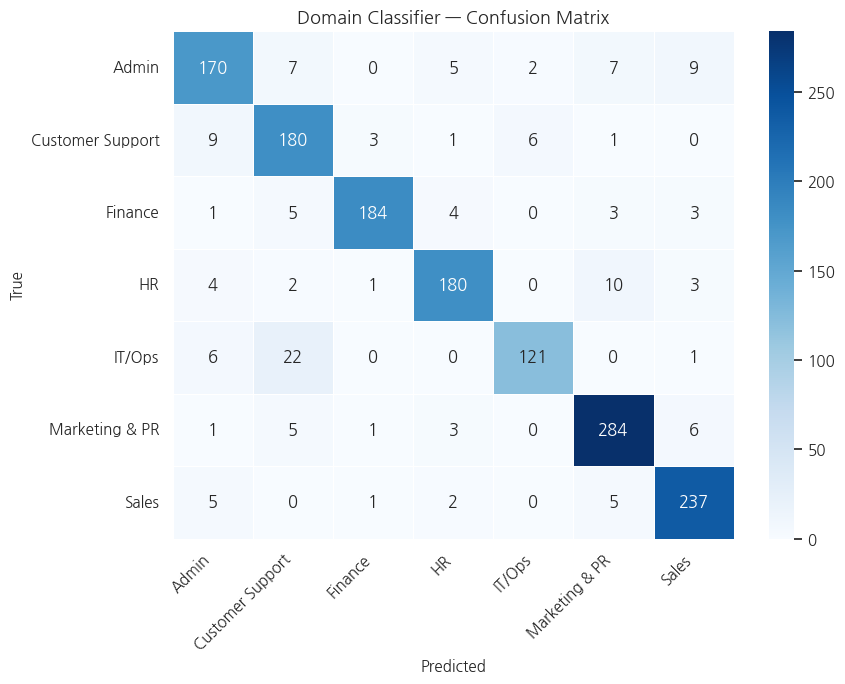

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/domain_confusion_matrix.png


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[train_domain] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/models


In [8]:
from train_domain import train_domain_classifier

domain_clf, le_domain = train_domain_classifier(X, df["domain"].values)

**2.  Intent Classifier 학습 + 평가**

Intent Classifier — 도메인별 학습 및 평가

[Admin] 샘플: 200 | 인텐트: 4 | K=5

[Intent [Admin]] K-Fold 결과
  Weighted F1 : 0.9699 ± 0.0100
  Macro F1    : 0.9699 ± 0.0100


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Admin]] Classification Report
              precision    recall  f1-score   support

          공지       0.94      0.96      0.95        50
       내부 보고       0.98      0.98      0.98        50
       자료 요청       1.00      1.00      1.00        50
       협조 요청       0.96      0.94      0.95        50

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



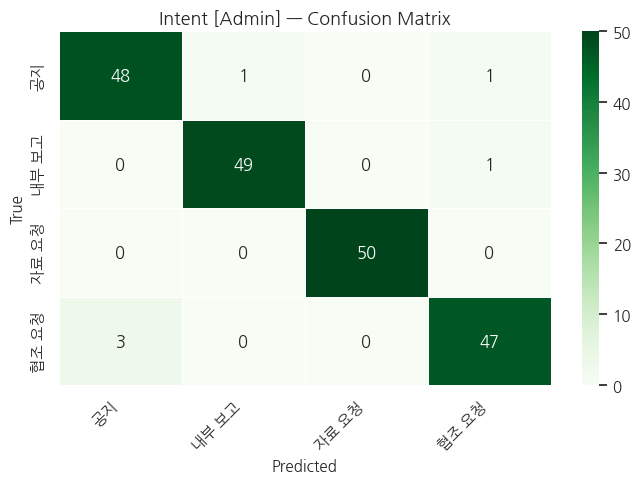

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Admin.png

[Customer Support] 샘플: 200 | 인텐트: 4 | K=5

[Intent [Customer Support]] K-Fold 결과
  Weighted F1 : 0.9799 ± 0.0100
  Macro F1    : 0.9799 ± 0.0100

[Intent [Customer Support]] Classification Report
              precision    recall  f1-score   support

    기술 지원 요청       1.00      0.94      0.97        50
       불만 접수       0.94      0.98      0.96        50
      사용법 문의       0.98      1.00      0.99        50
       환불 요청       1.00      1.00      1.00        50

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

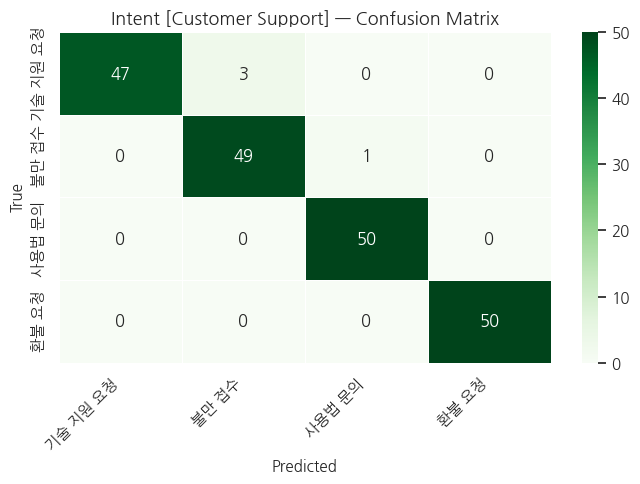

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Customer_Support.png

[Finance] 샘플: 200 | 인텐트: 4 | K=5

[Intent [Finance]] K-Fold 결과
  Weighted F1 : 0.9900 ± 0.0123
  Macro F1    : 0.9900 ± 0.0123

[Intent [Finance]] Classification Report
              precision    recall  f1-score   support

    비용 처리 문의       1.00      0.96      0.98        50
    세금계산서 요청       1.00      1.00      1.00        50
    입금 확인 요청       0.98      1.00      0.99        50
       정산 문의       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

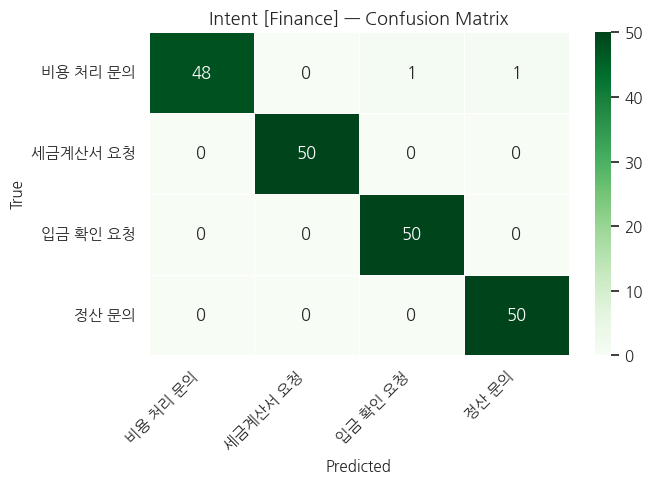

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Finance.png

[HR] 샘플: 200 | 인텐트: 4 | K=5

[Intent [HR]] K-Fold 결과
  Weighted F1 : 1.0000 ± 0.0000
  Macro F1    : 1.0000 ± 0.0000

[Intent [HR]] Classification Report
              precision    recall  f1-score   support

       면접 조율       1.00      1.00      1.00        50
   증명서 발급 요청       1.00      1.00      1.00        50
       채용 문의       1.00      1.00      1.00        50
       휴가 신청       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

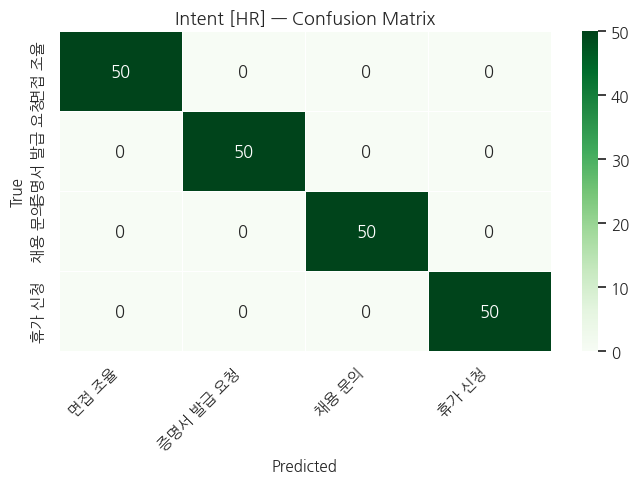

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_HR.png

[IT/Ops] 샘플: 150 | 인텐트: 3 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [IT/Ops]] K-Fold 결과
  Weighted F1 : 0.9933 ± 0.0134
  Macro F1    : 0.9933 ± 0.0134


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Intent [IT/Ops]] Classification Report
              precision    recall  f1-score   support

    계정 생성 요청       0.98      1.00      0.99        50
    권한 변경 요청       1.00      0.98      0.99        50
   시스템 오류 보고       1.00      1.00      1.00        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



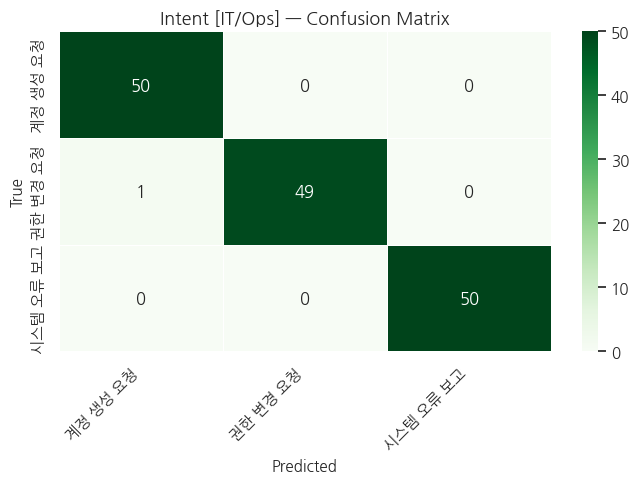

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_IT_Ops.png

[Marketing & PR] 샘플: 300 | 인텐트: 6 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Marketing & PR]] K-Fold 결과
  Weighted F1 : 0.9800 ± 0.0125
  Macro F1    : 0.9800 ± 0.0125

[Intent [Marketing & PR]] Classification Report


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

       광고 문의       0.98      0.98      0.98        50
     보도자료 요청       1.00      1.00      1.00        50
      인터뷰 요청       1.00      1.00      1.00        50
   콘텐츠 협업 문의       0.96      1.00      0.98        50
   행사/캠페인 문의       0.98      0.96      0.97        50
    협찬/제휴 제안       0.96      0.94      0.95        50

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



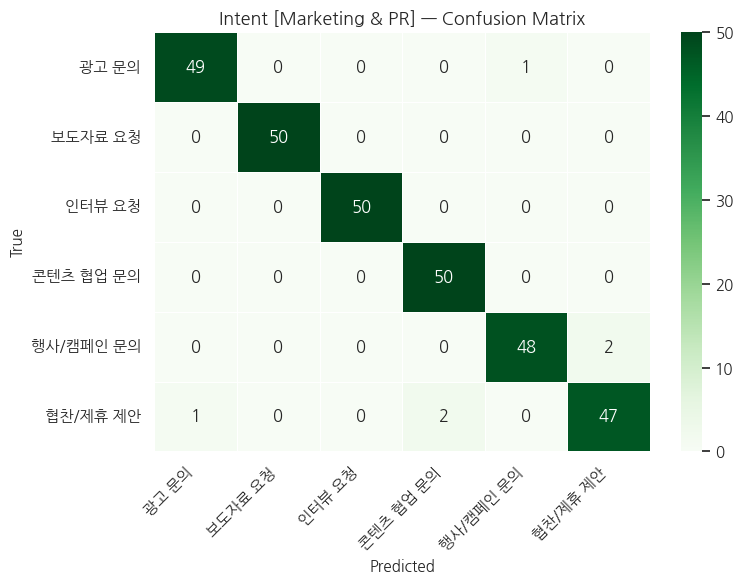

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Marketing_&_PR.png

[Sales] 샘플: 250 | 인텐트: 5 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Sales]] K-Fold 결과
  Weighted F1 : 0.9960 ± 0.0080
  Macro F1    : 0.9960 ± 0.0080


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Sales]] Classification Report
              precision    recall  f1-score   support

       가격 협상       1.00      1.00      1.00        50
       견적 요청       1.00      0.98      0.99        50
       계약 문의       1.00      1.00      1.00        50
    미팅 일정 조율       1.00      1.00      1.00        50
       제안 요청       0.98      1.00      0.99        50

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



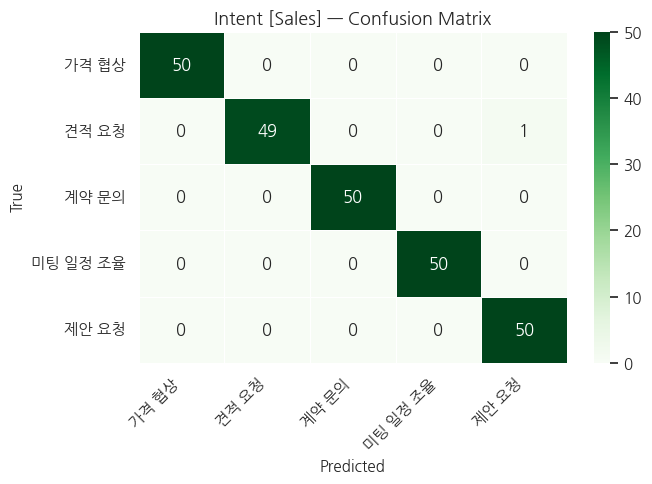

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Sales.png

[train_intent] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/models


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [9]:
from train_intent import train_intent_classifiers

intent_classifiers, intent_encoders = train_intent_classifiers(X, df)

## Ⅳ. 추론 파이프라인 테스트

1. 추론 파이프라인 로드 + 테스트

In [10]:
from inference import load_pipeline, predict_email

pipeline = load_pipeline()

test_emails = [
    # ── 정상 샘플 ────────────────────────────────────────────
    # Sales - 견적 요청
    "안녕하세요. 귀사의 클라우드 솔루션 도입을 검토 중입니다. 50인 규모 기준으로 견적서 부탁드립니다.",
    # HR - 채용 문의
    "안녕하세요. 넥스코어 채용팀입니다. 현재 백엔드 개발자 포지션 채용이 진행 중인지 문의드립니다. 지원 절차도 함께 안내 부탁드립니다.",
    # IT/Ops - 시스템 오류
    "안녕하세요. 오늘 오전부터 사내 ERP 시스템 로그인이 되지 않습니다. 긴급 기술 지원 요청드립니다.",
    # Finance - 세금계산서
    "안녕하세요. 지난달 납품 건에 대한 세금계산서 발행을 요청드립니다. 공급가액은 330만원입니다.",
    # Admin - 공지
    "안녕하세요. 이번주 금요일 오후 사내 전체 회의가 예정되어 있습니다. 전 임직원 필참 바랍니다.",
    # Customer Support - 불만
    "안녕하세요. 지난주에 구매한 제품에 불량이 발생했습니다. 교환 또는 환불 처리 요청드립니다.",

    # ── 노이즈 샘플 ──────────────────────────────────────────
    # Finance - 세금계산서 요청 (오타 + 구어체)
    "저번주에 물품 보냈는데 아직 계산셔가 안와서요. 빨리좀 확인부탁드림니다. 엄무에 차질생겨여.",
    # Finance - 입금 확인 (감정 + 재촉)
    "아... 진짜 급한데 3월분 대금이 아직 안들어왔어요. 확인좀 해주세여 빨리빨리요. 계좌번호 다시 드릴까요?",
    # Admin - 협조 요청 (맥락 생략)
    "회의실 예약좀여. 이번주 화요일 오후 2시에 4인용으로요. 30분~1시간 정도 필요해요.",
    # IT/Ops - 계정 (구어체 + 급함)
    "아 진짜 급한데요 비밀번호 여러번 틀렸더니 계정이 잠겼어요. 오전에 발표 있는데 빨리 풀어주실 수 있나요!!",
    # HR - 휴가 신청 (짧고 모호)
    "연차 내일 쓰고 싶어요. 팀장한테는 말씀 드렸는데 인사팀에도 따로 신청해야 하나요.",
    # Customer Support - 불만 (감정 섞임)
    "저번에도 같은 문제로 연락드렸는데 개선이 전혀 안됐어요. 이 정도면 이용을 계속 해야 할지 모르겠어요.",
    # Sales - 가격 협상 (직접적)
    "솔직히 말씀드리면 받은 견적이 예산 두배 수준이에요. 좀 조정 안되나요? 장기계약 생각하고 있거든요.",
    # Finance - 비용처리 (중의적 / Admin인지 Finance인지 애매)
    "저번 행사에 쓴 영수증 처리 다 됐나요? 총무팀에서 해야하는건지 재무팀에서 해야하는건지도 모르겠고..",
    # IT/Ops - 권한 (중의적 / IT인지 Admin인지 애매)
    "비밀번호 까먹었는데 누가 초기화해줘요? 로그인이 안돼서 업무를 못하고 있어요.",
    # Marketing & PR - 협찬 (구어체)
    "저희 유튜브 채널에서 귀사 제품 협찬 영상 제작 제안드립니다. 구독자 10만명이고요 조건 논의해봐요.",
]

print("=" * 60)
print("추론 테스트 (정상 6개 + 노이즈 10개)")
print("=" * 60)

for i, email in enumerate(test_emails):
    result  = predict_email(email, pipeline)
    flag    = "⚠️  Low confidence" if result["low_confidence"] else "✅"
    section = "── 노이즈 ──" if i == 6 else ""

    if i == 0:
        print("\n[ 정상 샘플 ]")
    if i == 6:
        print("\n[ 노이즈 샘플 ]")

    print(f"\n입력   : {email[:55]}...")
    print(f"  {flag}")
    print(f"  Domain : {result['domain']:<20} (confidence: {result['domain_confidence']})")
    print(f"  Intent : {result['intent']:<20} (confidence: {result['intent_confidence']})")
    if result["low_confidence"]:
        print(f"  Top-2  : {result['top2_domains']}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[load_pipeline]  파이프라인 로드 완료
추론 테스트 (정상 6개 + 노이즈 10개)

[ 정상 샘플 ]

입력   : 안녕하세요. 귀사의 클라우드 솔루션 도입을 검토 중입니다. 50인 규모 기준으로 견적서 부탁드립니다...
  ✅
  Domain : Sales                (confidence: 0.7599)
  Intent : 견적 요청                (confidence: 0.8585)

입력   : 안녕하세요. 넥스코어 채용팀입니다. 현재 백엔드 개발자 포지션 채용이 진행 중인지 문의드립니다. 지...
  ✅
  Domain : HR                   (confidence: 0.7115)
  Intent : 채용 문의                (confidence: 0.9426)

입력   : 안녕하세요. 오늘 오전부터 사내 ERP 시스템 로그인이 되지 않습니다. 긴급 기술 지원 요청드립니다...
  ✅
  Domain : Customer Support     (confidence: 0.7093)
  Intent : 기술 지원 요청             (confidence: 0.8754)

입력   : 안녕하세요. 지난달 납품 건에 대한 세금계산서 발행을 요청드립니다. 공급가액은 330만원입니다....
  ✅
  Domain : Finance              (confidence: 0.857)
  Intent : 세금계산서 요청             (confidence: 0.9547)

입력   : 안녕하세요. 이번주 금요일 오후 사내 전체 회의가 예정되어 있습니다. 전 임직원 필참 바랍니다....
  ✅
  Domain : Sales                (confidence: 0.4493)
  Intent : 미팅 일정 조율             (confidence: 0.8086)

입력   : 안녕하세요. 지난주에 구매한 제품에 불량이 발생했습니다. 교환 또는 환불 처리 요청드